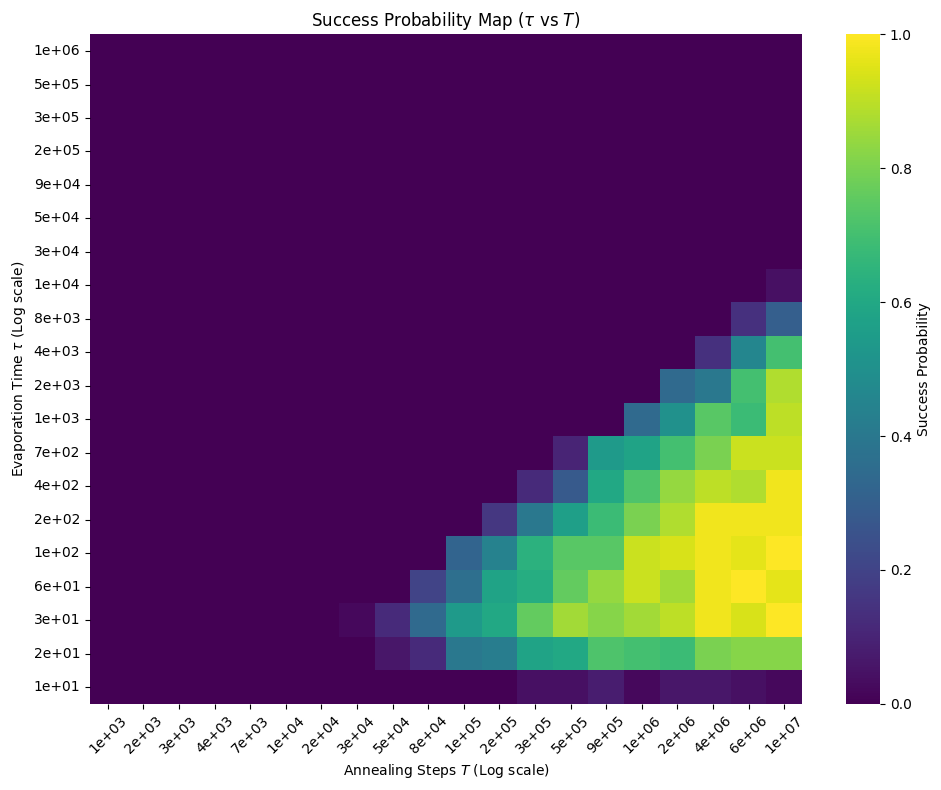

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("heatmap_data.csv")

# ピボットテーブルに変形
pivot_table = df.pivot(index='tau', columns='T', values='success_rate')

plt.figure(figsize=(10, 8))

# ヒートマップ描画
# 軸の数値をきれいにするため、Logフォーマットを意識
ax = sns.heatmap(pivot_table, cmap='viridis', annot=False, cbar_kws={'label': 'Success Probability'})

# 軸ラベルの修正（数値が多すぎると重なるため間引くなどの工夫が必要だが、ここではそのまま）
# matplotlibの機能で軸を対数っぽく見せる
ax.invert_yaxis() # 通常グラフは下が小さい値だがheatmapは上がindex 0。合わせるならinvert。
# ただしpivotのindex順序による。df.pivotはソートされるので、
# tauが小さい順に並んでいる。通常グラフ通り下を小、上を大にするならinvert_yaxis()が必要。

plt.xlabel(r'Annealing Steps $T$ (Log scale)')
plt.ylabel(r'Evaporation Time $\tau$ (Log scale)')
plt.title(r'Success Probability Map ($\tau$ vs $T$)')

# 軸の目盛りを対数表記の文字列に置き換える処理（簡易版）
# 実際のindex/columnsの値を取得
xticks = ax.get_xticks()
xlabels = [f"{float(pivot_table.columns[int(x)]):.0e}" for x in xticks]
ax.set_xticklabels(xlabels, rotation=45)

yticks = ax.get_yticks()
ylabels = [f"{float(pivot_table.index[int(y)]):.0e}" for y in yticks]
ax.set_yticklabels(ylabels, rotation=0)

plt.tight_layout()
plt.show()